<a href="https://colab.research.google.com/github/svetlanama/ai_practice/blob/dev/DZ_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/HalyshAnton/IT-Step-Pyton-AI/main/module3/data/House_Rent_Dataset.csv", index_col="Unnamed: 0")

[Інформація про дані](https://www.kaggle.com/datasets/iamsouravbanerjee/house-rent-prediction-dataset)

In [3]:
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2.0,10000.0,1100.0,Ground out of 2,NaN,NaN,Kolkata,Unfurnished,Bachelors/Family,2.0,Contact Owner
1,2022-05-13,2.0,20000.0,800.0,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1.0,NaN
2,2022-05-16,2.0,17000.0,1000.0,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1.0,Contact Owner
3,2022-07-04,2.0,10000.0,800.0,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1.0,Contact Owner
4,NaN,2.0,7500.0,850.0,1 out of 2,Carpet Area,NaN,Kolkata,Unfurnished,Bachelors,1.0,Contact Owner


In [4]:
df = df[['Size', 'Furnishing Status', 'City', 'Rent']]
df.head()

,Size,Furnishing Status,City,Rent
0,1100.0,Unfurnished,Kolkata,10000.0
1,800.0,Semi-Furnished,Kolkata,20000.0
2,1000.0,Semi-Furnished,Kolkata,17000.0
3,800.0,Unfurnished,Kolkata,10000.0
4,850.0,Unfurnished,Kolkata,7500.0


# Завдання 1
Ввиведіть основні числові характеристики даних, розділіть на тренувальну та тестову чатини. Цільова ознака `Rent`

In [5]:
numerical_summary = df.describe()
numerical_summary

,Size,Rent
count,4402.000000,4.369000e+03
mean,967.214675,3.461306e+04
std,636.118893,7.740818e+04
min,10.000000,1.200000e+03
25%,550.000000,1.000000e+04
50%,850.000000,1.600000e+04
75%,1200.000000,3.300000e+04
max,8000.000000,3.500000e+06


In [6]:
df.shape

(4746, 4)

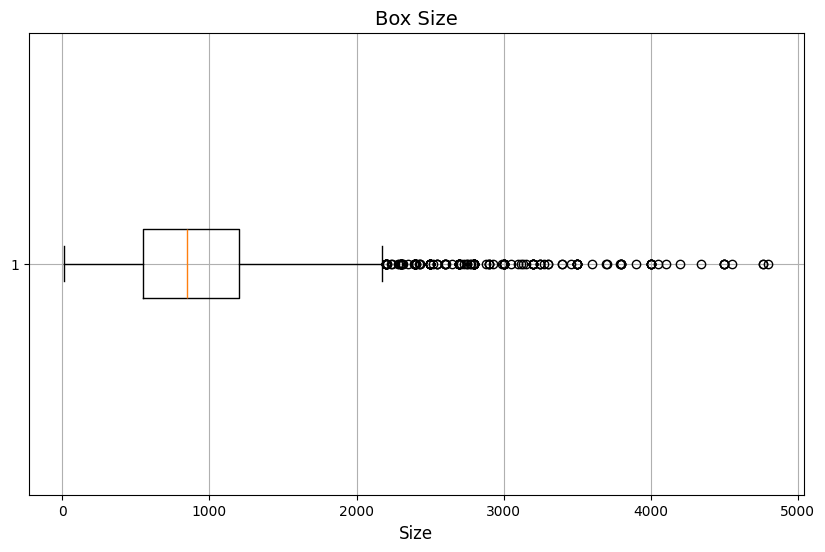

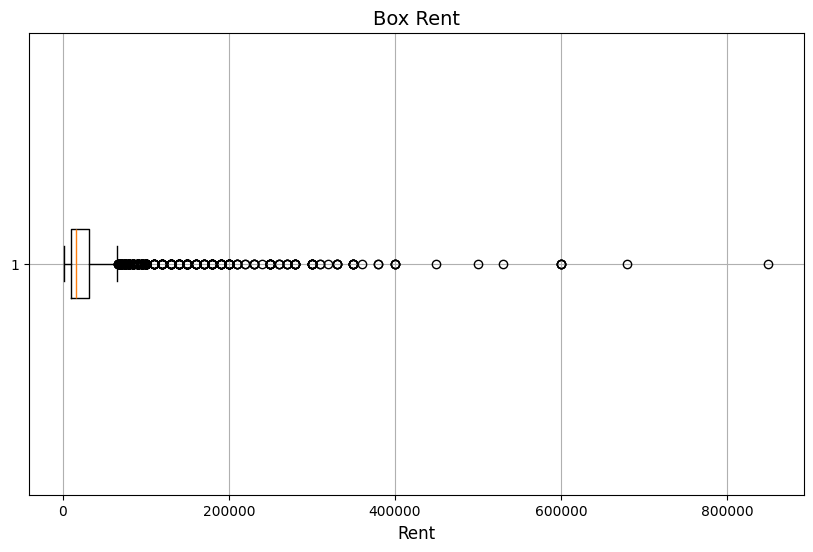

In [11]:
num_cols = df.select_dtypes(include=['number'])
for col in num_cols:
    plt.figure(figsize=(10, 6))

    # Select non empty data
    col_data = df[col].dropna()

    # Build box
    plt.boxplot(col_data, vert=False)
    plt.title(f'Box {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.grid(True)
    plt.show()

In [12]:
df = df[df['Rent'] < 200000 ]
df = df[df['Size'] < 2000]
df.describe()

,Size,Rent
count,3773.000000,3773.000000
mean,850.519746,25110.483170
std,417.231968,28235.848007
min,10.000000,1500.000000
25%,550.000000,10000.000000
50%,800.000000,15000.000000
75%,1100.000000,28000.000000
max,1975.000000,190000.000000


# Завдання 2
Створіть Pipeline для обробки числових стовпчиків(заповнення пропусків)

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Create Pipeline for for umeric columns
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean"))  # fill the empty with avg
])

numeric_pipeline

Pipeline(steps=[('imputer', SimpleImputer())])

In [15]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Rent"])
y = df["Rent"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_test, y_train, y_test

(        Size Furnishing Status       City
 640   1080.0       Unfurnished     Mumbai
 1478   550.0       Unfurnished        NaN
 4613  1800.0    Semi-Furnished  Hyderabad
 918    994.0    Semi-Furnished     Mumbai
 3680   700.0       Unfurnished    Chennai
 ...      ...               ...        ...
 1400   330.0         Furnished     Mumbai
 1614   550.0               NaN  Bangalore
 1047   710.0       Unfurnished     Mumbai
 4389  1250.0    Semi-Furnished  Hyderabad
 3957  1050.0       Unfurnished  Hyderabad
 
 [3018 rows x 3 columns],
         Size Furnishing Status       City
 109    220.0         Furnished    Kolkata
 4743  1750.0    Semi-Furnished  Hyderabad
 3306  1225.0    Semi-Furnished    Chennai
 1664   700.0    Semi-Furnished  Bangalore
 409   1000.0         Furnished    Kolkata
 ...      ...               ...        ...
 2077   850.0               NaN  Bangalore
 1613   800.0       Unfurnished  Bangalore
 4498   900.0         Furnished        NaN
 3512  1000.0    Semi-Furn

# Завдання 3
Створіть Pipeline для обробки категоріальних стовпчиків(заповнення пропусків та кодування)

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Create Pipeline for categorial columns
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),  # fill the empties with the most frequent values
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))    # Encoding categorial data
])

categorical_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

# Завдання 4
Об'єднайте попередні Pipeline в один ColumnTransformer

In [17]:
numerical_columns = ["Size"]
categorical_columns = ["Furnishing Status", "City"]

# Combime Pipeline into ColumnTransformer
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_columns),
    ("cat", categorical_pipeline, categorical_columns)
])

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer', SimpleImputer())]),
                                 ['Size']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Furnishing Status', 'City'])])

# Завдання 5
Створіть остаточну модель та натренуйте її

In [18]:
from sklearn.linear_model import LinearRegression

model = Pipeline(
    steps=[('prep', preprocessor),
           ('model', LinearRegression())]
)

model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer())]),
                                                  ['Size']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Furnishing Status',
                                                   'City'])])),
                ('model', LinearRegression())])

In [19]:
model['prep'].set_output(transform='pandas')
model['prep'].transform(X_train)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but OneHotEncoder was fitted without feature names
  warnings.warn(


,num__Size,cat__Furnishing Status_Furnished,cat__Furnishing Status_Semi-Furnished,cat__Furnishing Status_Unfurnished,cat__City_Bangalore,cat__City_Chennai,cat__City_Delhi,cat__City_Hyderabad,cat__City_Kolkata,cat__City_Mumbai
640,1080.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1478,550.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4613,1800.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
918,994.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3680,700.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
1400,330.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1614,550.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1047,710.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4389,1250.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


# Завдання 6
Виведіть основні метрики моделі

In [20]:
from sklearn import metrics as sk_metrics

def get_metrics(y_true, y_pred, name="model"):
    df = pd.DataFrame()
    df.loc["MAE", name] = sk_metrics.mean_absolute_error(y_true, y_pred)
    df.loc["RMSE", name] = sk_metrics.mean_squared_error(y_true, y_pred) ** 0.5
    df.loc["R2", name] = sk_metrics.r2_score(y_true, y_pred)
    return df.round(2)

all_metrics = pd.DataFrame()

y_pred = model.predict(X_train)
all_metrics['train'] = get_metrics(y_train, y_pred)

y_pred = model.predict(X_test)
all_metrics['test'] = get_metrics(y_test, y_pred)

all_metrics

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but OneHotEncoder was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but OneHotEncoder was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


,train,test
MAE,12707.37,12770.32
RMSE,21065.17,21902.02
R2,0.45,0.35


# Завдання 7
Збережіть модель, завантажте її та спрогнозуйте ціну автомобіля

In [22]:
data = pd.DataFrame({'Size': [900],
                     'Furnishing Status': ['Semi-Furnished'],
                     'City': ['Mumbai']})

data

,Size,Furnishing Status,City
0,900,Semi-Furnished,Mumbai


In [23]:
model.predict(data)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but OneHotEncoder was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


array([53704.04499368])